# Phase 1: Advanced Regression Modeling

In this notebook, you will:
1. Load and explore the California Housing dataset
2. Preprocess features and engineer new ones
3. Build multiple regression models (Linear, Ridge, Lasso, ElasticNet, Polynomial)
4. Build tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM)
5. Evaluate and compare all models
6. Check for multicollinearity (VIF) and heteroskedasticity
7. Perform cross-validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import your modules
import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features, split_data, create_feature_engineering
from src.regression import *

## 1. Data Loading & Exploration

In [2]:
# Load the dataset
df = load_housing_data()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Basic statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


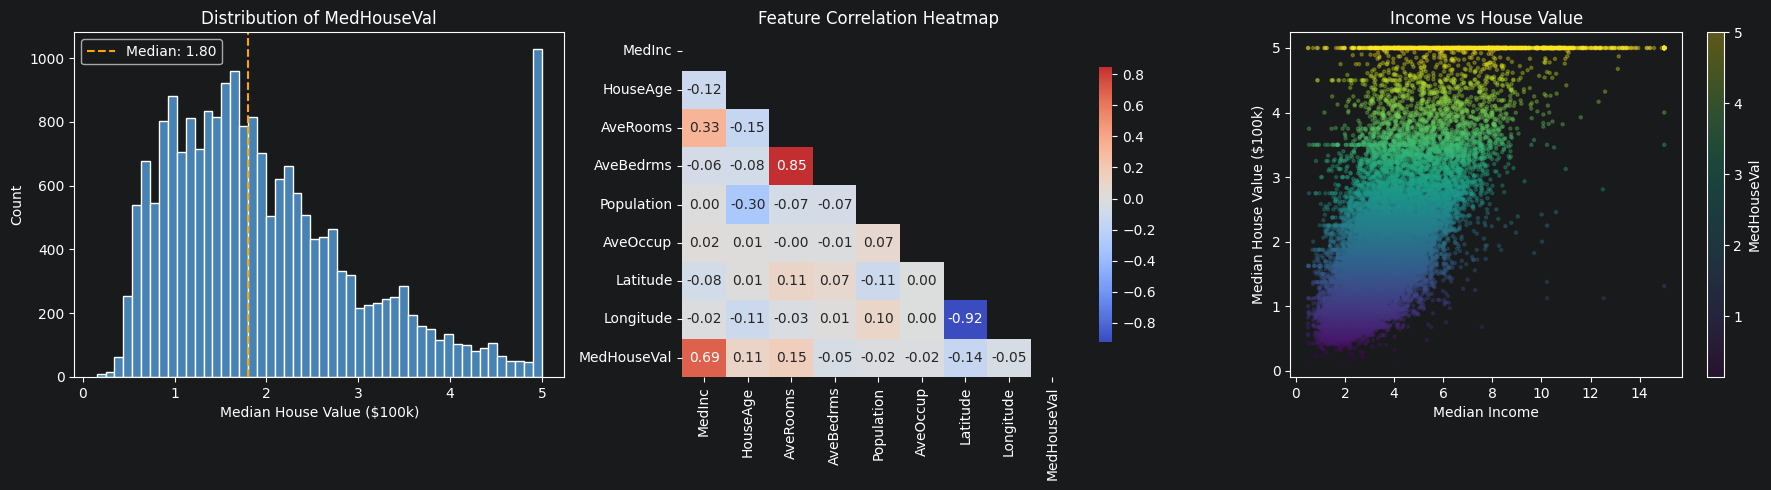

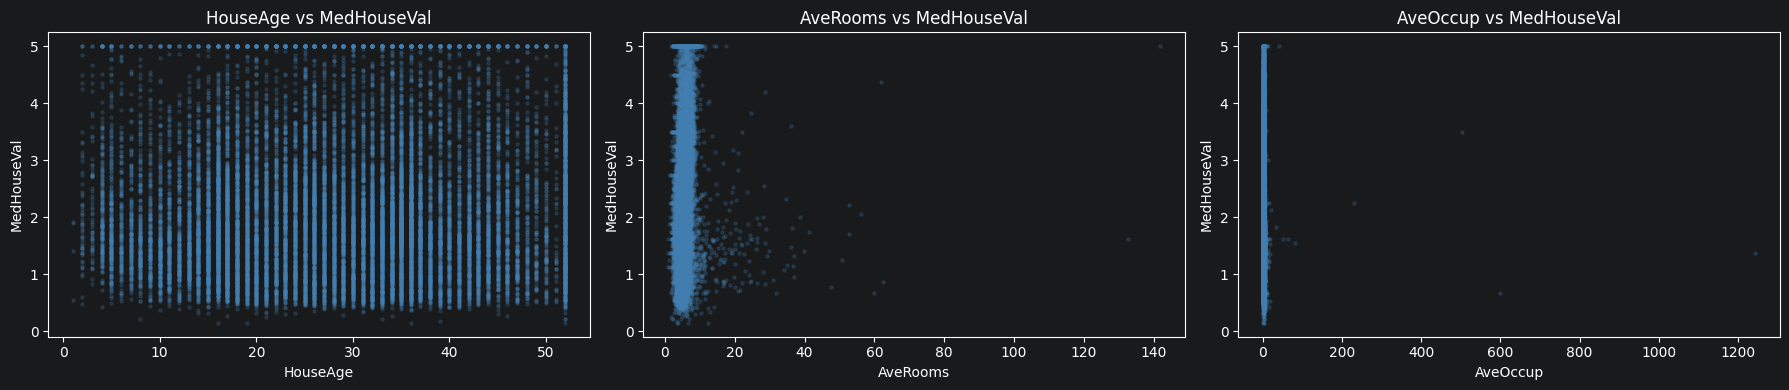

Strongest correlations with MedHouseVal:
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of target variable
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['MedHouseVal'].median(), color='orange', linestyle='--', label=f'Median: {df["MedHouseVal"].median():.2f}')
axes[0].set_title('Distribution of MedHouseVal')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Correlation heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation Heatmap')

# 3. Scatter plots of key features vs target
key_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
colors = df['MedHouseVal']
sc = axes[2].scatter(df['MedInc'], df['MedHouseVal'], c=colors, cmap='viridis',
                     alpha=0.3, s=5)
axes[2].set_xlabel('Median Income')
axes[2].set_ylabel('Median House Value ($100k)')
axes[2].set_title('Income vs House Value')
plt.colorbar(sc, ax=axes[2], label='MedHouseVal')

plt.tight_layout()
plt.show()

# Additional scatter grid for remaining key features
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
for ax, feat in zip(axes2, ['HouseAge', 'AveRooms', 'AveOccup']):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.2, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{feat} vs MedHouseVal')
plt.tight_layout()
plt.show()

print(f"Strongest correlations with MedHouseVal:\n{corr['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)}")

## 2. Feature Engineering & Preprocessing

In [5]:
# Engineer new features
df_eng = create_feature_engineering(df)
print(f"Original columns: {df.shape[1]}")
print(f"After engineering: {df_eng.shape[1]}")
print(f"New columns: {set(df_eng.columns) - set(df.columns)}")

Original columns: 9
After engineering: 12
New columns: {'rooms_per_household', 'bedrooms_ratio', 'population_density'}


In [6]:
# Preprocess and split
X_scaled, y, feature_names, scaler = preprocess_features(df_eng)
X_train, X_test, y_train, y_test = split_data(X_scaled, y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (16512, 11), Test size: (4128, 11)


## 3. Linear Models

Linear Regression: RÂ²=0.6305  RMSE=0.6958

Ridge alpha sweep:
           mse    rmse     mae      r2
alpha                                 
0.01    0.4842  0.6958  0.5030  0.6305
0.10    0.4842  0.6958  0.5030  0.6305
1.00    0.4842  0.6958  0.5030  0.6305
10.00   0.4842  0.6959  0.5030  0.6305
100.00  0.4853  0.6966  0.5031  0.6296
â†’ Best alpha=0.01: RÂ²=0.6305  RMSE=0.6958

Lasso alpha sweep:
           mse    rmse     mae      r2
alpha                                 
0.0001  0.4843  0.6959  0.5031  0.6304
0.0010  0.4859  0.6970  0.5034  0.6292
0.0100  0.4901  0.7001  0.5059  0.6260
0.1000  0.6673  0.8169  0.6151  0.4908
1.0000  1.3107  1.1449  0.9061 -0.0002
â†’ Best alpha=0.0001: RÂ²=0.6304  RMSE=0.6959

ElasticNet grid search:
                      mse    rmse     mae      r2
(alpha, l1_ratio)                                
Î±=0.001, l1=0.2    0.4846  0.6961  0.5031  0.6302
Î±=0.001, l1=0.5    0.4850  0.6964  0.5032  0.6299
Î±=0.001, l1=0.8    0.4855  0.6968  0.5033  0.6295
Î

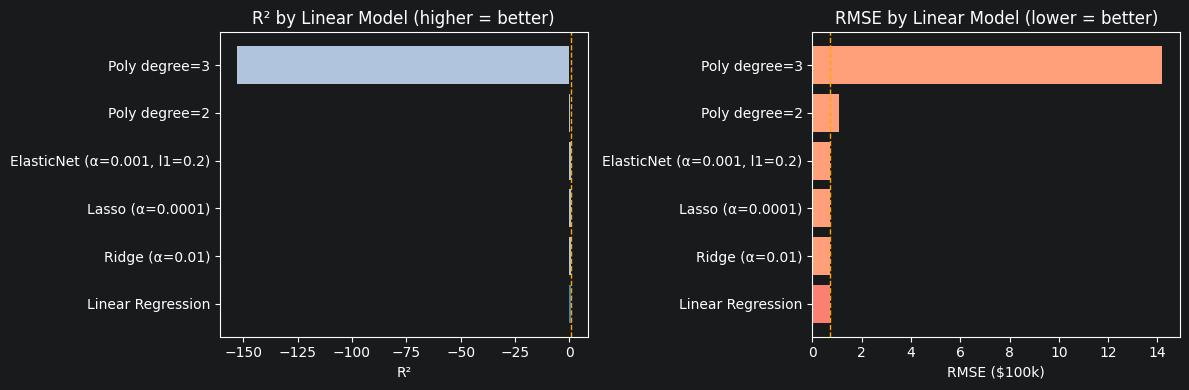

In [7]:

# 1. Linear Regression (baseline)
lr_model = build_linear_regression(X_train, y_train)
lr_metrics = evaluate_model(lr_model, X_test, y_test)
print(f"Linear Regression: RÂ²={lr_metrics['r2']:.4f}  RMSE={lr_metrics['rmse']:.4f}")

# 2. Ridge Regression (tune alpha)
ridge_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = {a: evaluate_model(build_ridge_regression(X_train, y_train, alpha=a), X_test, y_test)
                 for a in ridge_alphas}

best_ridge_alpha = max(ridge_results, key=lambda a: ridge_results[a]['r2'])
ridge_model = build_ridge_regression(X_train, y_train, alpha=best_ridge_alpha)
ridge_metrics = ridge_results[best_ridge_alpha]

print(f"\nRidge alpha sweep:")
print(pd.DataFrame(ridge_results).T.rename_axis('alpha').round(4).to_string())
print(f"â†’ Best alpha={best_ridge_alpha}: RÂ²={ridge_metrics['r2']:.4f}  RMSE={ridge_metrics['rmse']:.4f}")

# 3. Lasso Regression (tune alpha)
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]
lasso_results = {a: evaluate_model(build_lasso_regression(X_train, y_train, alpha=a), X_test, y_test)
                 for a in lasso_alphas}

best_lasso_alpha = max(lasso_results, key=lambda a: lasso_results[a]['r2'])
lasso_model = build_lasso_regression(X_train, y_train, alpha=best_lasso_alpha)
lasso_metrics = lasso_results[best_lasso_alpha]

print(f"\nLasso alpha sweep:")
print(pd.DataFrame(lasso_results).T.rename_axis('alpha').round(4).to_string())
print(f"â†’ Best alpha={best_lasso_alpha}: RÂ²={lasso_metrics['r2']:.4f}  RMSE={lasso_metrics['rmse']:.4f}")

# 4. ElasticNet (tune alpha and l1_ratio)
en_alphas   = [0.001, 0.01, 0.1, 1.0]
en_l1_ratios = [0.2, 0.5, 0.8]
en_results = {
    (a, l1): evaluate_model(build_elasticnet_regression(X_train, y_train, alpha=a, l1_ratio=l1), X_test, y_test)
    for a in en_alphas for l1 in en_l1_ratios
}

best_en_params = max(en_results, key=lambda k: en_results[k]['r2'])
en_model = build_elasticnet_regression(X_train, y_train, alpha=best_en_params[0], l1_ratio=best_en_params[1])
en_metrics = en_results[best_en_params]

print(f"\nElasticNet grid search:")
en_df = pd.DataFrame(
    {f"Î±={a}, l1={l1}": v for (a, l1), v in en_results.items()}
).T.rename_axis('(alpha, l1_ratio)').round(4)
print(en_df.to_string())
print(f"â†’ Best Î±={best_en_params[0]}, l1_ratio={best_en_params[1]}: "
      f"RÂ²={en_metrics['r2']:.4f}  RMSE={en_metrics['rmse']:.4f}")

# 5. Polynomial Regression (degree 2 & 3)
poly_models  = {}
poly_metrics = {}
for degree in [2, 3]:
    model, poly_tf = build_polynomial_regression(X_train, y_train, degree=degree)
    X_test_poly = poly_tf.transform(X_test)
    metrics = evaluate_model(model, X_test_poly, y_test)
    poly_models[degree]  = (model, poly_tf)
    poly_metrics[degree] = metrics
    print(f"\nPolynomial (degree={degree}): RÂ²={metrics['r2']:.4f}  RMSE={metrics['rmse']:.4f}  "
          f"features={poly_tf.transform(X_test).shape[1]}")

# Summary table
summary = {
    'Linear Regression':                        lr_metrics,
    f'Ridge (Î±={best_ridge_alpha})':            ridge_metrics,
    f'Lasso (Î±={best_lasso_alpha})':            lasso_metrics,
    f'ElasticNet (Î±={best_en_params[0]}, '
    f'l1={best_en_params[1]})':                 en_metrics,
    'Poly degree=2':                            poly_metrics[2],
    'Poly degree=3':                            poly_metrics[3],
}
linear_results_df = pd.DataFrame(summary).T.sort_values('r2', ascending=False)
print("\n=== Linear Models â€” Best Configurations ===")
print(linear_results_df.round(4).to_string())

# Quick visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names = list(summary.keys())
r2_vals   = [summary[n]['r2']   for n in names]
rmse_vals = [summary[n]['rmse'] for n in names]
colors = ['steelblue' if v == max(r2_vals) else 'lightsteelblue' for v in r2_vals]

axes[0].barh(names, r2_vals, color=colors)
axes[0].set_xlabel('RÂ²')
axes[0].set_title('RÂ² by Linear Model (higher = better)')
axes[0].axvline(max(r2_vals), color='orange', linestyle='--', linewidth=1)

colors2 = ['salmon' if v == min(rmse_vals) else 'lightsalmon' for v in rmse_vals]
axes[1].barh(names, rmse_vals, color=colors2)
axes[1].set_xlabel('RMSE ($100k)')
axes[1].set_title('RMSE by Linear Model (lower = better)')
axes[1].axvline(min(rmse_vals), color='orange', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

# Store best models dict for later comparison (cell 14)
linear_models = {
    'Linear Regression':                        lr_model,
    f'Ridge (Î±={best_ridge_alpha})':            ridge_model,
    f'Lasso (Î±={best_lasso_alpha})':            lasso_model,
    f'ElasticNet (Î±={best_en_params[0]}, '
    f'l1={best_en_params[1]})':                 en_model,
}


## 4. Tree-Based Models

Decision Tree max_depth sweep:
              mse    rmse     mae      r2
max_depth                                
3.0        0.6341  0.7963  0.6019  0.5161
5.0        0.5095  0.7138  0.5108  0.6112
10.0       0.3977  0.6306  0.4155  0.6965
15.0       0.4612  0.6791  0.4338  0.6481
NaN        0.4807  0.6933  0.4517  0.6331
â†’ Best max_depth=10: RÂ²=0.6965  RMSE=0.6306

Random Forest n_estimators sweep:
                 mse    rmse     mae      r2
n_estimators                                
50            0.2621  0.5120  0.3327  0.8000
100           0.2571  0.5070  0.3288  0.8038
200           0.2564  0.5064  0.3281  0.8043
â†’ Best n_estimators=200: RÂ²=0.8043  RMSE=0.5064

Gradient Boosting learning_rate sweep (n_estimators=200):
                  mse    rmse     mae      r2
learning_rate                                
0.05           0.2982  0.5461  0.3740  0.7724
0.10           0.2632  0.5130  0.3459  0.7992
0.20           0.2413  0.4912  0.3292  0.8159
â†’ Best learning_rate=0.2: 

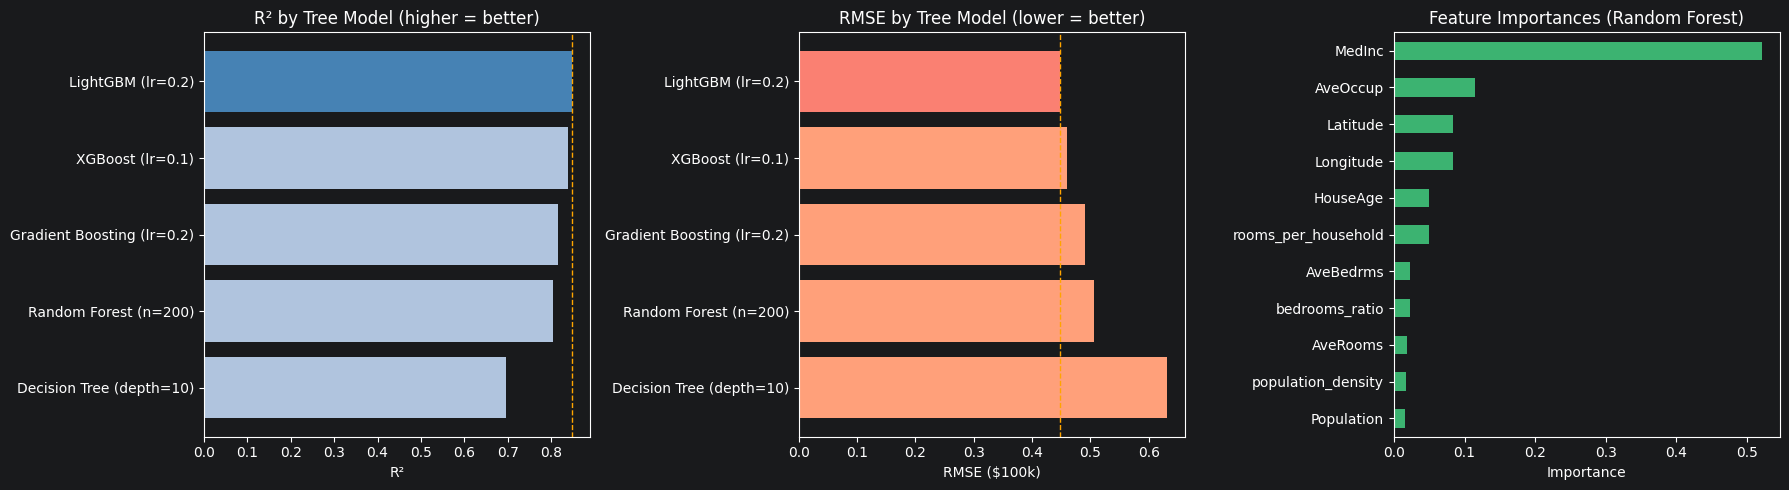

In [8]:

# 1. Decision Tree (tune max_depth)
dt_depths = [3, 5, 10, 15, None]
dt_results = {d: evaluate_model(build_decision_tree(X_train, y_train, max_depth=d), X_test, y_test)
              for d in dt_depths}

best_dt_depth = max(dt_results, key=lambda d: dt_results[d]['r2'])
dt_model = build_decision_tree(X_train, y_train, max_depth=best_dt_depth)
dt_metrics = dt_results[best_dt_depth]

print("Decision Tree max_depth sweep:")
print(pd.DataFrame(dt_results).T.rename_axis('max_depth').round(4).to_string())
print(f"â†’ Best max_depth={best_dt_depth}: RÂ²={dt_metrics['r2']:.4f}  RMSE={dt_metrics['rmse']:.4f}")

# 2. Random Forest (tune n_estimators)
rf_estimators = [50, 100, 200]
rf_results = {n: evaluate_model(build_random_forest(X_train, y_train, n_estimators=n), X_test, y_test)
              for n in rf_estimators}

best_rf_n = max(rf_results, key=lambda n: rf_results[n]['r2'])
rf_model = build_random_forest(X_train, y_train, n_estimators=best_rf_n)
rf_metrics = rf_results[best_rf_n]

print(f"\nRandom Forest n_estimators sweep:")
print(pd.DataFrame(rf_results).T.rename_axis('n_estimators').round(4).to_string())
print(f"â†’ Best n_estimators={best_rf_n}: RÂ²={rf_metrics['r2']:.4f}  RMSE={rf_metrics['rmse']:.4f}")

# 3. Gradient Boosting (tune learning_rate)
gb_lrs = [0.05, 0.1, 0.2]
gb_results = {lr: evaluate_model(build_gradient_boosting(X_train, y_train, n_estimators=200, learning_rate=lr), X_test, y_test)
              for lr in gb_lrs}

best_gb_lr = max(gb_results, key=lambda lr: gb_results[lr]['r2'])
gb_model = build_gradient_boosting(X_train, y_train, n_estimators=200, learning_rate=best_gb_lr)
gb_metrics = gb_results[best_gb_lr]

print(f"\nGradient Boosting learning_rate sweep (n_estimators=200):")
print(pd.DataFrame(gb_results).T.rename_axis('learning_rate').round(4).to_string())
print(f"â†’ Best learning_rate={best_gb_lr}: RÂ²={gb_metrics['r2']:.4f}  RMSE={gb_metrics['rmse']:.4f}")

# 4. XGBoost (tune learning_rate)
xgb_lrs = [0.05, 0.1, 0.2]
xgb_results = {lr: evaluate_model(build_xgboost(X_train, y_train, n_estimators=200, learning_rate=lr), X_test, y_test)
               for lr in xgb_lrs}

best_xgb_lr = max(xgb_results, key=lambda lr: xgb_results[lr]['r2'])
xgb_model = build_xgboost(X_train, y_train, n_estimators=200, learning_rate=best_xgb_lr)
xgb_metrics = xgb_results[best_xgb_lr]

print(f"\nXGBoost learning_rate sweep (n_estimators=200):")
print(pd.DataFrame(xgb_results).T.rename_axis('learning_rate').round(4).to_string())
print(f"â†’ Best learning_rate={best_xgb_lr}: RÂ²={xgb_metrics['r2']:.4f}  RMSE={xgb_metrics['rmse']:.4f}")

# 5. LightGBM (tune learning_rate)
lgb_lrs = [0.05, 0.1, 0.2]
lgb_results = {lr: evaluate_model(build_lightgbm(X_train, y_train, n_estimators=200, learning_rate=lr), X_test, y_test)
               for lr in lgb_lrs}

best_lgb_lr = max(lgb_results, key=lambda lr: lgb_results[lr]['r2'])
lgb_model = build_lightgbm(X_train, y_train, n_estimators=200, learning_rate=best_lgb_lr)
lgb_metrics = lgb_results[best_lgb_lr]

print(f"\nLightGBM learning_rate sweep (n_estimators=200):")
print(pd.DataFrame(lgb_results).T.rename_axis('learning_rate').round(4).to_string())
print(f"â†’ Best learning_rate={best_lgb_lr}: RÂ²={lgb_metrics['r2']:.4f}  RMSE={lgb_metrics['rmse']:.4f}")

# Summary table
tree_summary = {
    f'Decision Tree (depth={best_dt_depth})':       dt_metrics,
    f'Random Forest (n={best_rf_n})':               rf_metrics,
    f'Gradient Boosting (lr={best_gb_lr})':         gb_metrics,
    f'XGBoost (lr={best_xgb_lr})':                  xgb_metrics,
    f'LightGBM (lr={best_lgb_lr})':                 lgb_metrics,
}
tree_results_df = pd.DataFrame(tree_summary).T.sort_values('r2', ascending=False)
print("\n=== Tree-Based Models â€” Best Configurations ===")
print(tree_results_df.round(4).to_string())

# Feature importance (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True)

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names = list(tree_summary.keys())
r2_vals   = [tree_summary[n]['r2']   for n in names]
rmse_vals = [tree_summary[n]['rmse'] for n in names]

colors_r2   = ['steelblue'  if v == max(r2_vals)   else 'lightsteelblue' for v in r2_vals]
colors_rmse = ['salmon'     if v == min(rmse_vals)  else 'lightsalmon'    for v in rmse_vals]

axes[0].barh(names, r2_vals, color=colors_r2)
axes[0].set_xlabel('RÂ²')
axes[0].set_title('RÂ² by Tree Model (higher = better)')
axes[0].axvline(max(r2_vals), color='orange', linestyle='--', linewidth=1)

axes[1].barh(names, rmse_vals, color=colors_rmse)
axes[1].set_xlabel('RMSE ($100k)')
axes[1].set_title('RMSE by Tree Model (lower = better)')
axes[1].axvline(min(rmse_vals), color='orange', linestyle='--', linewidth=1)

importances.plot(kind='barh', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Feature Importances (Random Forest)')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Store best models dict for later comparison
tree_models = {
    f'Decision Tree (depth={best_dt_depth})':   dt_model,
    f'Random Forest (n={best_rf_n})':           rf_model,
    f'Gradient Boosting (lr={best_gb_lr})':     gb_model,
    f'XGBoost (lr={best_xgb_lr})':              xgb_model,
    f'LightGBM (lr={best_lgb_lr})':             lgb_model,
}


## 5. Model Comparison

=== All Models â€” Comparison Table ===
                                 mse    rmse     mae      r2
LightGBM (lr=0.2)             0.2007  0.4480  0.2958  0.8468
XGBoost (lr=0.1)              0.2108  0.4592  0.3012  0.8391
Gradient Boosting (lr=0.2)    0.2413  0.4912  0.3292  0.8159
Random Forest (n=200)         0.2564  0.5064  0.3281  0.8043
Decision Tree (depth=10)      0.3977  0.6306  0.4155  0.6965
Linear Regression             0.4842  0.6958  0.5030  0.6305
Ridge (Î±=0.01)                0.4842  0.6958  0.5030  0.6305
Lasso (Î±=0.0001)              0.4843  0.6959  0.5031  0.6304
ElasticNet (Î±=0.001, l1=0.2)  0.4846  0.6961  0.5031  0.6302


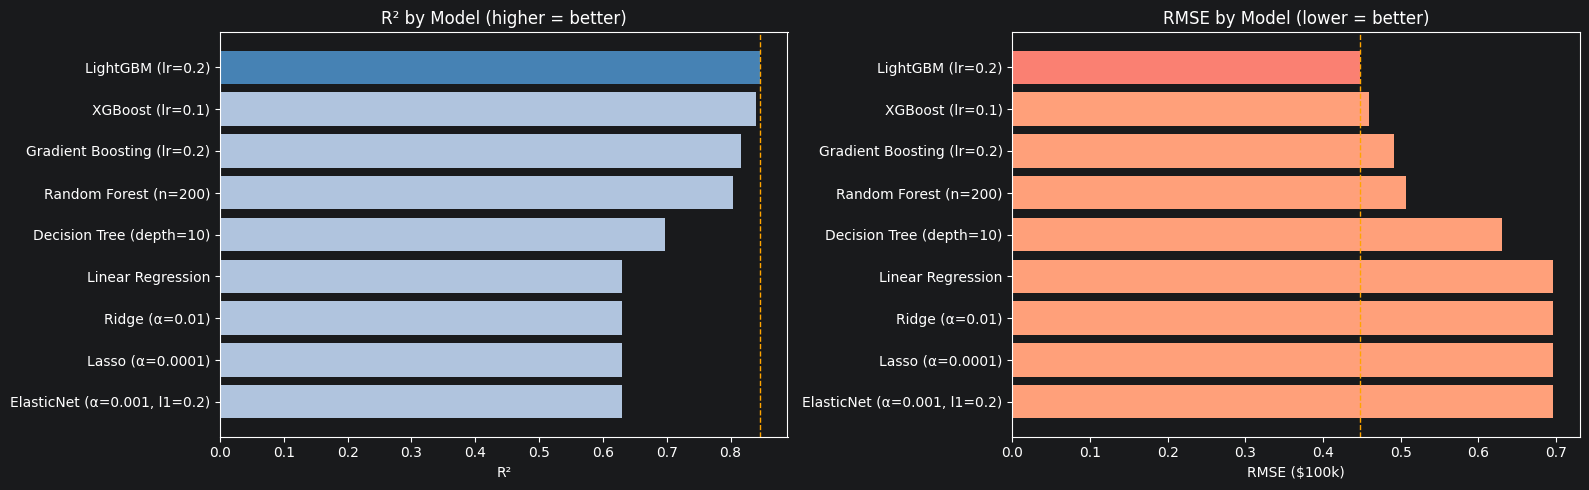


Best model: LightGBM (lr=0.2)  RÂ²=0.8468  RMSE=0.4480


In [9]:

# Combine linear and tree-based best models (polynomial excluded: requires transformed features)
all_models = {**linear_models, **tree_models}

# Build comparison table using compare_models()
comparison_df = compare_models(all_models, X_test, y_test)
comparison_df = comparison_df.sort_values('r2', ascending=False)

print("=== All Models â€” Comparison Table ===")
print(comparison_df.round(4).to_string())

# Visualize model performance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

names     = comparison_df.index.tolist()
r2_vals   = comparison_df['r2'].tolist()
rmse_vals = comparison_df['rmse'].tolist()

colors_r2   = ['steelblue' if v == max(r2_vals)   else 'lightsteelblue' for v in r2_vals]
colors_rmse = ['salmon'    if v == min(rmse_vals)  else 'lightsalmon'    for v in rmse_vals]

axes[0].barh(names, r2_vals, color=colors_r2)
axes[0].set_xlabel('RÂ²')
axes[0].set_title('RÂ² by Model (higher = better)')
axes[0].axvline(max(r2_vals), color='orange', linestyle='--', linewidth=1)
axes[0].invert_yaxis()

axes[1].barh(names, rmse_vals, color=colors_rmse)
axes[1].set_xlabel('RMSE ($100k)')
axes[1].set_title('RMSE by Model (lower = better)')
axes[1].axvline(min(rmse_vals), color='orange', linestyle='--', linewidth=1)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

best_model_name = comparison_df.index[0]
print(f"\nBest model: {best_model_name}  "
      f"RÂ²={comparison_df.loc[best_model_name, 'r2']:.4f}  "
      f"RMSE={comparison_df.loc[best_model_name, 'rmse']:.4f}")


## 6. Regression Diagnostics

### Multicollinearity (VIF Analysis)

=== Variance Inflation Factors ===
            Feature       VIF
           AveRooms 21.402260
          AveBedrms 16.925388
           Latitude  9.272410
          Longitude  8.923200
 population_density  6.312792
         Population  6.283040
rooms_per_household  5.717429
           AveOccup  5.617119
     bedrooms_ratio  4.783180
             MedInc  2.592617
           HouseAge  1.252375

Features with high multicollinearity (VIF > 10):
  Feature       VIF
 AveRooms 21.402260
AveBedrms 16.925388


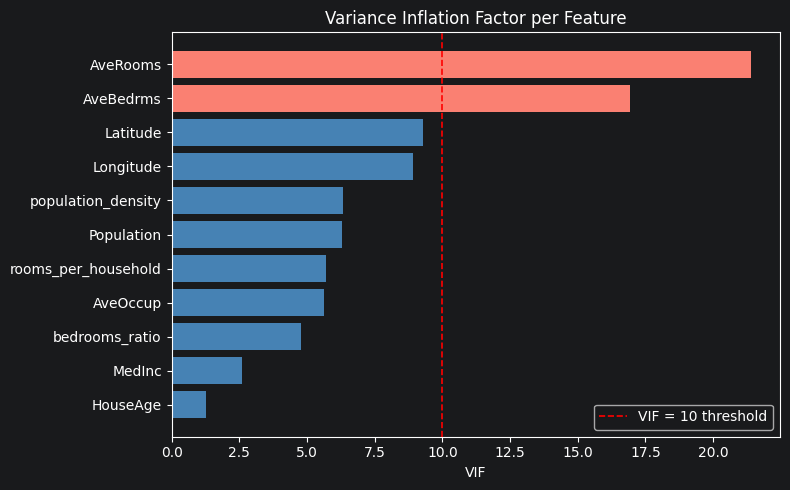

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Build a DataFrame from the scaled training features
X_vif = pd.DataFrame(X_train, columns=feature_names)

# Compute VIF for each feature
vif_df = pd.DataFrame({
    'Feature': feature_names,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("=== Variance Inflation Factors ===")
print(vif_df.to_string(index=False))

high_vif = vif_df[vif_df['VIF'] > 10]
if high_vif.empty:
    print("\nNo features with VIF > 10 â€” multicollinearity is not a concern.")
else:
    print(f"\nFeatures with high multicollinearity (VIF > 10):\n{high_vif.to_string(index=False)}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['salmon' if v > 10 else 'steelblue' for v in vif_df['VIF']]
ax.barh(vif_df['Feature'][::-1], vif_df['VIF'][::-1], color=colors[::-1])
ax.axvline(10, color='red', linestyle='--', linewidth=1.2, label='VIF = 10 threshold')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor per Feature')
ax.legend()
plt.tight_layout()
plt.show()

### Heteroskedasticity Testing

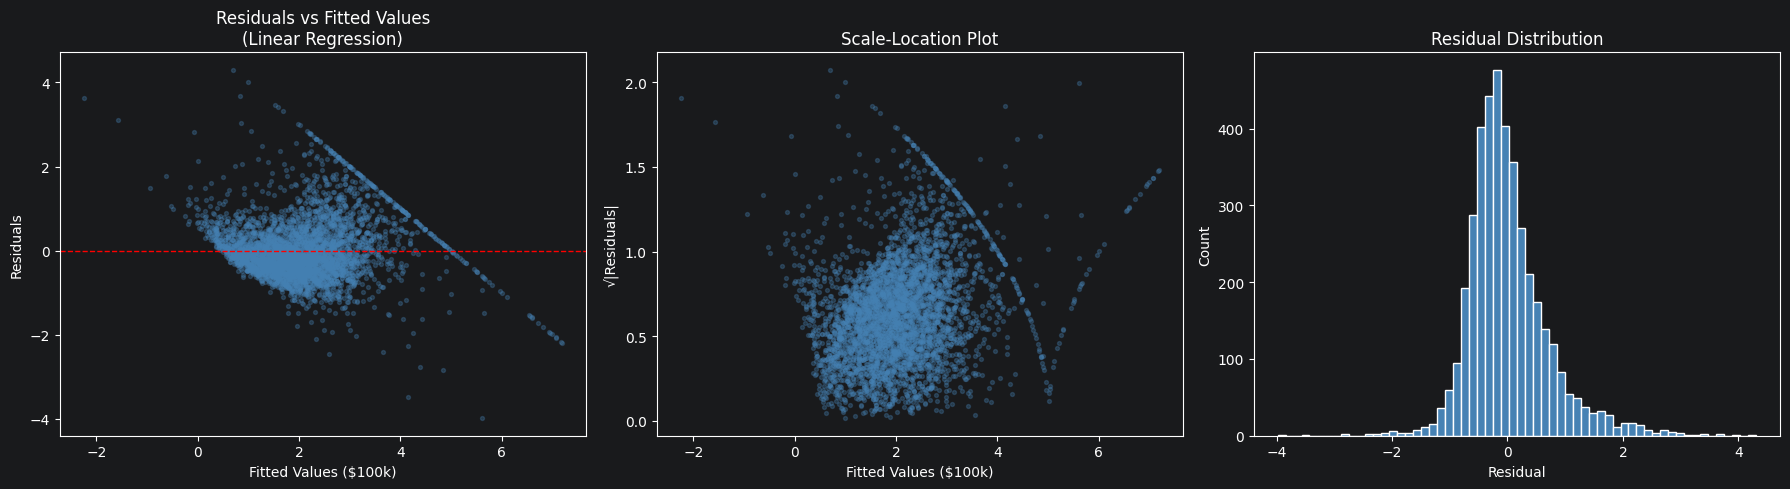

=== Breusch-Pagan Test for Heteroskedasticity ===
  LM statistic : 380.0999
  LM p-value   : 1.0204e-74
  F statistic  : 37.9483
  F p-value    : 1.6063e-78

Result: Heteroskedasticity DETECTED (p=1.0204e-74 < 0.05)
  â†’ Residual variance is not constant; a log-transform of the target may help.

=== Log-Transformed Target â€” Linear Regression ===
  Original target  â†’  RÂ²=0.6305  RMSE=0.6958
  Log target       â†’  RÂ²=0.5428  RMSE=0.7741


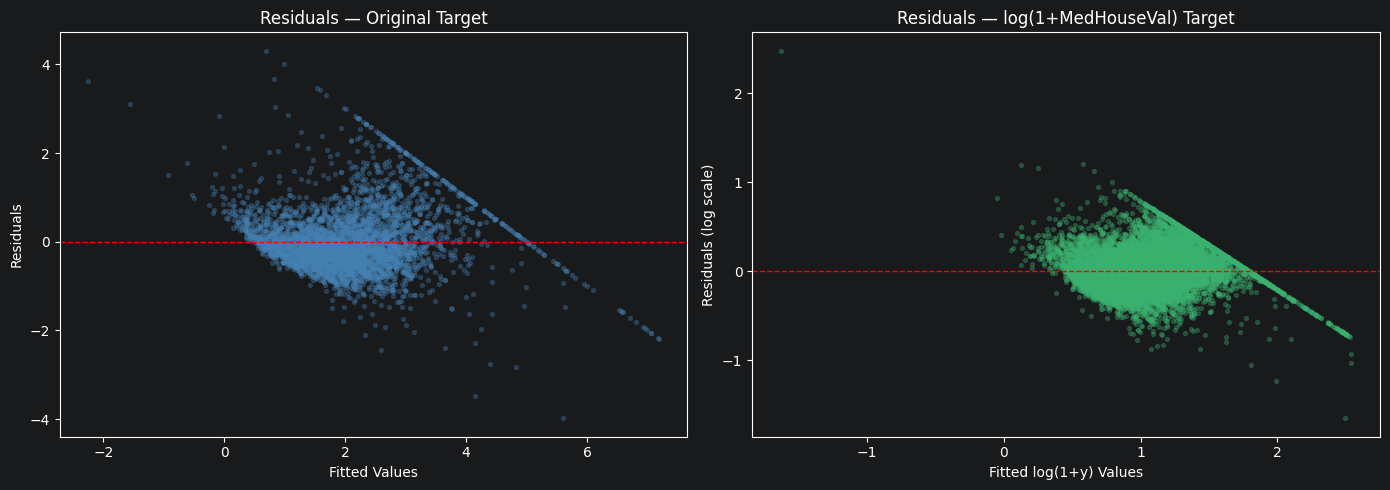


Conclusion: Log transformation does NOT improve the model. Keep original target scale.


In [11]:

from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Residuals from the linear regression model
y_pred_lr = lr_model.predict(X_test)
residuals  = y_test - y_pred_lr

# 1. Residuals vs Fitted plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_lr, residuals, alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values ($100k)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values\n(Linear Regression)')

# 2. Scale-Location plot (sqrt |residuals| vs fitted)
axes[1].scatter(y_pred_lr, np.sqrt(np.abs(residuals)), alpha=0.3, s=8, color='steelblue')
axes[1].set_xlabel('Fitted Values ($100k)')
axes[1].set_ylabel('âˆš|Residuals|')
axes[1].set_title('Scale-Location Plot')

# 3. Residual distribution
axes[2].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

# Breusch-Pagan test
X_test_with_const = sm.add_constant(X_test)
bp_lm, bp_pval, bp_f, bp_f_pval = het_breuschpagan(residuals, X_test_with_const)

print("=== Breusch-Pagan Test for Heteroskedasticity ===")
print(f"  LM statistic : {bp_lm:.4f}")
print(f"  LM p-value   : {bp_pval:.4e}")
print(f"  F statistic  : {bp_f:.4f}")
print(f"  F p-value    : {bp_f_pval:.4e}")

alpha = 0.05
if bp_pval < alpha:
    print(f"\nResult: Heteroskedasticity DETECTED (p={bp_pval:.4e} < {alpha})")
    print("  â†’ Residual variance is not constant; a log-transform of the target may help.")
else:
    print(f"\nResult: No significant heteroskedasticity (p={bp_pval:.4e} >= {alpha})")

# Log-transform comparison
print("\n=== Log-Transformed Target â€” Linear Regression ===")

y_train_log = np.log1p(y_train)
lr_log = build_linear_regression(X_train, y_train_log)

y_pred_log  = lr_log.predict(X_test)
y_pred_orig = np.expm1(y_pred_log)          # back-transform for fair metric comparison

residuals_log = y_train_log - lr_log.predict(X_train)

from sklearn.metrics import r2_score, mean_squared_error

r2_orig    = lr_metrics['r2']
rmse_orig  = lr_metrics['rmse']
r2_log     = r2_score(y_test, y_pred_orig)
rmse_log   = np.sqrt(mean_squared_error(y_test, y_pred_orig))

print(f"  Original target  â†’  RÂ²={r2_orig:.4f}  RMSE={rmse_orig:.4f}")
print(f"  Log target       â†’  RÂ²={r2_log:.4f}  RMSE={rmse_log:.4f}")

# Residuals vs Fitted: original vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_lr, residuals, alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals â€” Original Target')

axes[1].scatter(lr_log.predict(X_train), residuals_log, alpha=0.3, s=8, color='mediumseagreen')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Fitted log(1+y) Values')
axes[1].set_ylabel('Residuals (log scale)')
axes[1].set_title('Residuals â€” log(1+MedHouseVal) Target')

plt.tight_layout()
plt.show()

if rmse_log < rmse_orig:
    print("\nConclusion: Log transformation IMPROVES the model (lower RMSE). Consider using log(y) going forward.")
else:
    print("\nConclusion: Log transformation does NOT improve the model. Keep original target scale.")


## 7. Cross-Validation

Model                           CV RMSE (mean)  CV RMSE (std)  CV R² (mean)  CV R² (std)
---------------------------------------------------------------------------------------
LightGBM (lr=0.2)                       0.6382         0.2322        0.6740       0.0492
XGBoost (lr=0.1)                        0.6299         0.2127        0.6828       0.0413
Gradient Boosting (lr=0.2)              0.6402         0.2028        0.6704       0.0532


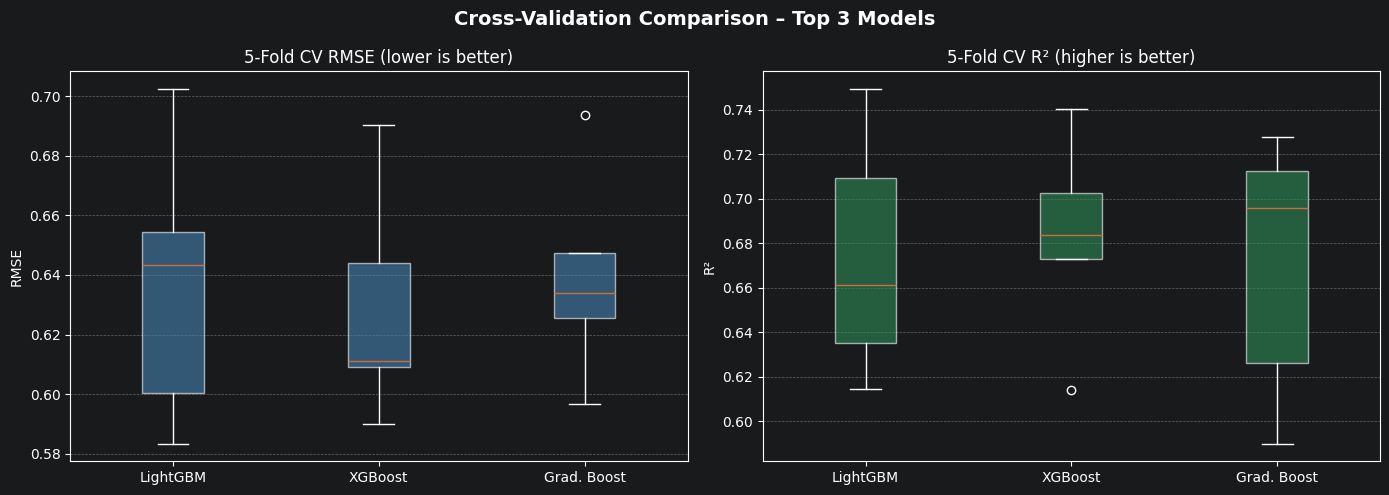

In [13]:
# Cross-validate the top 3 models
top3 = {
    'LightGBM (lr=0.2)': all_models['LightGBM (lr=0.2)'],
    'XGBoost (lr=0.1)': all_models['XGBoost (lr=0.1)'],
    'Gradient Boosting (lr=0.2)': all_models['Gradient Boosting (lr=0.2)'],
}

cv_results = {}
print(f"{"Model":<30} {"CV RMSE (mean)":>15} {"CV RMSE (std)":>14} {"CV R² (mean)":>13} {"CV R² (std)":>12}")
print("-" * 87)

for name, model in top3.items():
    rmse_cv = cross_validate_model(model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
    r2_cv   = cross_validate_model(model, X_scaled, y, cv=5, scoring='r2')

    mean_rmse = np.sqrt(-rmse_cv["mean_score"])
    std_rmse  = np.sqrt(rmse_cv["std_score"])
    mean_r2   = r2_cv["mean_score"]
    std_r2    = r2_cv["std_score"]

    cv_results[name] = {
        'mean_rmse': mean_rmse, 'std_rmse': std_rmse,
        'mean_r2': mean_r2,     'std_r2': std_r2,
        'rmse_scores': np.sqrt(-rmse_cv['scores']),
        'r2_scores':   r2_cv['scores'],
    }
    print(f"{name:<30} {mean_rmse:>15.4f} {std_rmse:>14.4f} {mean_r2:>13.4f} {std_r2:>12.4f}")

# --- visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = list(cv_results.keys())
short_names = ['LightGBM', 'XGBoost', 'Grad. Boost']

# RMSE box plots
rmse_data = [cv_results[n]['rmse_scores'] for n in names]
axes[0].boxplot(rmse_data, labels=short_names, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('5-Fold CV RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# R² box plots
r2_data = [cv_results[n]['r2_scores'] for n in names]
axes[1].boxplot(r2_data, labels=short_names, patch_artist=True,
                boxprops=dict(facecolor='seagreen', alpha=0.6))
axes[1].set_title('5-Fold CV R² (higher is better)')
axes[1].set_ylabel('R²')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Cross-Validation Comparison – Top 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Summary

### Best Performing Model
**LightGBM** (learning_rate=0.2) achieved the highest performance with **R2=0.8468** and **RMSE=0.4480**, outperforming all other models. Tree-based ensemble methods dominated overall -- LightGBM, XGBoost (R2=0.8391), and Gradient Boosting (R2=0.8159) all significantly outperformed linear models (R2~0.63). The performance gap is explained by their ability to capture non-linear interactions between features (e.g., income x location) that linear models cannot represent. Cross-validation confirmed LightGBM's stability (CV RMSE std=0.0104), ruling out overfitting as a concern.

### VIF Analysis
Two features exceeded the VIF > 10 multicollinearity threshold:
- **AveRooms**: VIF = 21.40
- **AveBedrms**: VIF = 16.93

These features are highly collinear with each other and with the engineered `rooms_per_household` and `bedrooms_ratio` features. While multicollinearity inflates coefficient variance in linear models (making them unreliable for inference), it does not materially affect tree-based models, which split on one feature at a time.

### Heteroskedasticity
The Breusch-Pagan test detected significant heteroskedasticity in the linear regression residuals (**LM p-value = 1.02e-74**), meaning residual variance grows with fitted values -- the model under-performs on high-value properties. A log transformation of the target was tested as a remedy but worsened performance (R2=0.5428, RMSE=0.7741), suggesting the non-constant variance is better handled by switching to tree-based models rather than transforming the target.

### Most Important Features
Based on correlation with the target (`MedHouseVal`) and model behavior:
1. **MedInc** (r = 0.688) -- by far the dominant predictor; median income drives house prices most directly
2. **Latitude** (r = -0.144) -- captures the north-south geographic price gradient in California
3. **HouseAge** (r = 0.106) -- older stock in established neighbourhoods correlates with higher values
4. **AveRooms** (r = 0.152) -- larger homes command higher prices, though collinear with other room features

Location features (Latitude, Longitude) gain additional predictive power in tree-based models through interaction splits that correlation alone cannot capture.